# Fast & Slow Extraction

This is a quick implementation of the Chain of Extraction + Fast & Slow thinking idea for text-to-JSON task.

## Imports

In [30]:
import json
import sys
from typing import Annotated, Any

from litellm import completion
from loguru import logger
from openai import OpenAI
from pydantic import BaseModel, Field

from agent_k.setup.load_43_101 import list_43_101_reports

# Configs
CLIENT = OpenAI()
TEMPERATURE = 0.5
MODEL = "gpt-4o-mini"
TOP_P = 0.95
LOG_LEVEL = "DEBUG"

In [31]:
logger.remove()
logger.add(sys.stderr, level=LOG_LEVEL)

5

## Schemas

In [32]:
class MineralSiteMetadata(BaseModel):
    mineral_site_name: str = Field(
        ..., description="The name of the mineral site that the report is about"
    )
    country: str = Field(
        ..., description="The country where the mineral site is located"
    )
    state_or_province: str = Field(
        ..., description="The state or province where the mineral site is located"
    )
    total_grade: str = Field(
        default="Not Found",
        description='The total grade of all the nickel deposits in percentage format (e.g. 0.35% will be "0.35")',
    )
    total_tonnage: str = Field(
        default="Not Found",
        description='The total tonnage of all the nickel deposits in million tonnes (e.g. 123.4 Mt will be "123.4")',
    )
    top_1_deposit_type: str = Field(
        default="Not Found",
        description="The most likely deposit type of the mineral site",
    )
    top_1_deposit_environment: str = Field(
        default="Not Found",
        description="The most likely deposit environment of the mineral site",
    )


schema = MineralSiteMetadata.model_json_schema()
print(json.dumps(schema, indent=4))

{
    "properties": {
        "mineral_site_name": {
            "description": "The name of the mineral site that the report is about",
            "title": "Mineral Site Name",
            "type": "string"
        },
        "country": {
            "description": "The country where the mineral site is located",
            "title": "Country",
            "type": "string"
        },
        "state_or_province": {
            "description": "The state or province where the mineral site is located",
            "title": "State Or Province",
            "type": "string"
        },
        "total_grade": {
            "default": "Not Found",
            "description": "The total grade of all the nickel deposits in percentage format (e.g. 0.35% will be \"0.35\")",
            "title": "Total Grade",
            "type": "string"
        },
        "total_tonnage": {
            "default": "Not Found",
            "description": "The total tonnage of all the nickel deposits in million tonne

In [33]:
class Example1(BaseModel):
    name: str
    address: str
    total_attendees: int
    oldest_attendee: str


class Example2(BaseModel):
    product_name: str
    product_type: str
    price: float
    discount: float


class Example3(BaseModel):
    address: str
    province: str
    country: str
    total_sales: float


schema_example1 = json.dumps(Example1.model_json_schema())
schema_example2 = json.dumps(Example2.model_json_schema())
schema_example3 = json.dumps(Example3.model_json_schema())
# replace "{" with "{{" and "}" with "}}" to be used in the multi-line prompt
schema_example1 = schema_example1.replace("{", "{{").replace("}", "}}")
schema_example2 = schema_example2.replace("{", "{{").replace("}", "}}")
schema_example3 = schema_example3.replace("{", "{{").replace("}", "}}")
print(schema_example1)
print(schema_example2)
print(schema_example3)

{{"properties": {{"name": {{"title": "Name", "type": "string"}}, "address": {{"title": "Address", "type": "string"}}, "total_attendees": {{"title": "Total Attendees", "type": "integer"}}, "oldest_attendee": {{"title": "Oldest Attendee", "type": "string"}}}}, "required": ["name", "address", "total_attendees", "oldest_attendee"], "title": "Example1", "type": "object"}}
{{"properties": {{"product_name": {{"title": "Product Name", "type": "string"}}, "product_type": {{"title": "Product Type", "type": "string"}}, "price": {{"title": "Price", "type": "number"}}, "discount": {{"title": "Discount", "type": "number"}}}}, "required": ["product_name", "product_type", "price", "discount"], "title": "Example2", "type": "object"}}
{{"properties": {{"address": {{"title": "Address", "type": "string"}}, "province": {{"title": "Province", "type": "string"}}, "country": {{"title": "Country", "type": "string"}}, "total_sales": {{"title": "Total Sales", "type": "number"}}}}, "required": ["address", "provin

## Prompts

In [34]:
SCHEMA_DECOMPOSE_SYS_PROMPT = """You are a helpful agent that groups entities in a JSON schema into two categories:
1. Simple entities in the JSON schema that can be extracted directly from the text.
2. Complex entities in the JSON schema that require reasoning or additional information to be extracted. Complex entities may include composite entities that need further decomposition or non-composite entities that require extra context for extraction.

You should enclose your reasoning within <thinking> XML tags and output the result within <output> XML tags."""

DECOMPOSE_USER_PROMPT_TEMPLATE = """# Example 1
Given the following JSON schema:
```
{{"properties": {{"name": {{"title": "Name", "type": "string"}}, "address": {{"title": "Address", "type": "string"}}, "total_attendees": {{"title": "Total Attendees", "type": "integer"}}, "oldest_attendee": {{"title": "Oldest Attendee", "type": "string"}}}}, "required": ["name", "address", "total_attendees", "oldest_attendee"], "title": "Example", "type": "object"}}
```
Output:
<thinking>
"name" and "address" are not complex entities and can be extracted directly from the text. "total_attendees" is likely a complex entity because it requires extracting individual attendees and counting them. Oldest attendee is a complex entity because it requires extracting the oldest attendee from the list of attendees.
</thinking>
<output>
1. Simple entities: ["name", "address"]
2. Complex entities: ["total_attendees", "oldest_attendee"]
</output>

# Example 2
Given the following JSOn schema:
```
{{"properties": {{"product_name": {{"title": "Product Name", "type": "string"}}, "product_type": {{"title": "Product Type", "type": "string"}}, "price": {{"title": "Price", "type": "number"}}, "discount": {{"title": "Discount", "type": "number"}}}}, "required": ["product_name", "product_type", "price", "discount"], "title": "Example2", "type": "object"}}
```
Output:
<thinking>
"product_name", "product_type", "price", and "discount" are all not complex entities and can be extracted directly from the text. "discount" is likely a complex entity because it requires extracting the discounted price and the original price from the text and then calculating the discount.
</thinking>
<output>
1. Simple entities: ["product_name", "product_type", "price"]
2. Complex entities: ["discount"]
</output>

# Example 3
Given the following JSON schema:
```
{{"properties": {{"address": {{"title": "Address", "type": "string"}}, "province": {{"title": "Province", "type": "string"}}, "country": {{"title": "Country", "type": "string"}}, "total_sales": {{"title": "Total Sales", "type": "number"}}}}, "required": ["address", "province", "country", "total_sales"], "title": "Example3", "type": "object"}}
```
Output:
<thinking>
"address", "province", and "country" are not complex entities and can be extracted directly from the text. "total_sales" is a complex entity because it requires extracting separate sale entities and then summing the sale values.
</thinking>
<output>
1. Simple entities: ["address", "province", "country"]
2. Complex entities: ["total_sales"]
</output>

# Example 4
Given the following JSON schema:
```
{json_schema}
```
Output:
"""


# Batch Extraction
PDF_AGENT_SYSTEM_PROMPT = """SEE OPENAI ASSISTANT DASHBOARD"""

PDF_AGENT_USER_PROMPT = """JSON schema provided: {json_schema}

Not take a deep breath and think step by step."""

# Deep Extraction
DEEP_EXTRACT_SYSTEM_PROMPT = """SEE OPENAI ASSISTANT DASHBOARD"""

DEEP_EXTRACT_USER_PROMPT = """Question: What's the {field} of the mineral site in the attached 43-101 report?
{field} description: {description}
{field} data type: {dtype}
{field} default value: {default}

Please enclose your reasoning within <thinking> XML tags and output the result within <output> XML tags. Please only include the final result in <output> XML tags and nothing else.

Now take a deep breath and think step by step."""


CORRECT_EXTRACT_SYSTEM_PROMPT = """SEE OPENAI ASSISTANT DASHBOARD"""

CORRECT_EXTRACT_USER_PROMPT = """Please correct the following extraction results based on the feedback and previous extraction messages.
Extraction results: {extraction_results}
Feedback: {feedback}
Previous extraction messages: {messages}
The JSON schema is: {json_schema}
Please enclose your reasoning within <thinking> XML tags and output the result within <json> XML tags."""

VALIDATOR_SYSTEM_PROMPT = """You are a helpful agent that validates the extracted results against the JSON schema and the previous extraction messages.

You should follow the following guidelines:
1. Double check the extracted results against the JSON schema, ensuring the data type and value are correct.
2. Double check the extracted values and make sure they only include the answer without any additional information or filler words.

Please enclose your reasoning within <thinking> XML tags, feedback in <feedback> XML tags, and output the result within <output> XML tags. Finally, output the result within <output> XML tags. If the extraction result is incorrect, output "NO" in the <output> XML tags. Otherwise, output "YES" in the <output> XML tags."""

VALIDATOR_USER_PROMPT = """Please validate the following extraction result based on the previous extraction messages.
Extraction result: {extraction_results}
Previous extraction messages: {messages}
The JSON schema is: {json_schema}"""

## Helper Functions

### Split JSON Schema

In [35]:
def split_json_schema(schema: dict, field_lists: list[list[str]]) -> list[dict]:
    """
    Splits a JSON schema into multiple schemas based on provided field lists.

    Args:
        schema (dict): The input JSON schema.
        field_lists (list of list of str): Each inner list contains fields for a separate schema.

    Returns:
        list of dict: A list of JSON schemas corresponding to each field list.
    """
    # Extract properties and required fields from the original schema
    original_properties = schema.get("properties", {})
    original_required = set(schema.get("required", []))

    schemas = []
    for field_list in field_lists:
        new_schema = {"type": "object", "properties": {}, "required": []}
        # Extract properties and required fields based on the field list
        for field in field_list:
            if field in original_properties:
                new_schema["properties"][field] = original_properties[field]
            if field in original_required:
                new_schema["required"].append(field)

        # Remove 'required' if empty
        if not new_schema["required"]:
            new_schema.pop("required")

        schemas.append(new_schema)

    return schemas


field_lists = [
    ["mineral_site_name", "state_or_province", "country"],
    ["total_grade", "total_tonnage"],
    ["top_1_deposit_type", "top_1_deposit_environment"],
    [],
]
result = split_json_schema(schema, field_lists)
for i, res in enumerate(result):
    print(f"Schema {i + 1}:", res)

Schema 1: {'type': 'object', 'properties': {'mineral_site_name': {'description': 'The name of the mineral site that the report is about', 'title': 'Mineral Site Name', 'type': 'string'}, 'state_or_province': {'description': 'The state or province where the mineral site is located', 'title': 'State Or Province', 'type': 'string'}, 'country': {'description': 'The country where the mineral site is located', 'title': 'Country', 'type': 'string'}}, 'required': ['mineral_site_name', 'state_or_province', 'country']}
Schema 2: {'type': 'object', 'properties': {'total_grade': {'default': 'Not Found', 'description': 'The total grade of all the nickel deposits in percentage format (e.g. 0.35% will be "0.35")', 'title': 'Total Grade', 'type': 'string'}, 'total_tonnage': {'default': 'Not Found', 'description': 'The total tonnage of all the nickel deposits in million tonnes (e.g. 123.4 Mt will be "123.4")', 'title': 'Total Tonnage', 'type': 'string'}}}
Schema 3: {'type': 'object', 'properties': {'to

### Parse JSON Code Block

In [36]:
def parse_json_code_block(content: str) -> dict[str, Any]:
    """Parse the JSON code block from the assistant response."""
    try:
        json_code_block = content.split("<json>")[1].split("</json>")[0]
        return json.loads(json_code_block)
    except Exception as e:
        logger.error(f"Failed to parse JSON code block: {e}")
        logger.error(f"LLM response: {content}")
        return {}

### Prompt OpenAI Assistant

In [37]:
from openai.types.beta import Assistant


def prompt_openai_assistant(assistant: Assistant, messages: list[dict]) -> str:
    thread = CLIENT.beta.threads.create(messages=messages)

    # Use the create and poll SDK helper to create a run and poll the status of
    # the run until it's in a terminal state.
    run = CLIENT.beta.threads.runs.create_and_poll(
        thread_id=thread.id,
        assistant_id=assistant.id,
    )
    if run.status == "completed":
        messages = list(CLIENT.beta.threads.messages.list(thread_id=thread.id))
    try:
        message_content = messages[0].content[0].text
    except IndexError as e:
        logger.exception(f"{e}.`messages`: {messages}")

    annotations = message_content.annotations
    citations = []
    for index, annotation in enumerate(annotations):
        message_content.value = message_content.value.replace(
            annotation.text, f"[{index}]"
        )
        if file_citation := getattr(annotation, "file_citation", None):
            cited_file = CLIENT.files.retrieve(file_citation.file_id)
            citations.append(f"[{index}] {cited_file.filename}")

    logger.debug(message_content.value)
    # logger.debug("\n".join(citations))

    return message_content.value

### Extract from PDF

In [38]:
def batch_extract(
    pdf_path: str,
    json_schema: dict,
) -> str:
    """
    Extract entities from a PDF file using OpenAI Assistant.
    """

    json_schema_str = json.dumps(json_schema)

    assistant = CLIENT.beta.assistants.retrieve("asst_dbMIxMYwSocPIKpZ3KLnadWB")

    filename_to_id_map = list_43_101_reports()
    filename = pdf_path.split("/")[-1]
    file_id = filename_to_id_map[filename]

    messages = [
        {
            "role": "user",
            "content": PDF_AGENT_USER_PROMPT.format(
                json_schema=json_schema_str,
            ),
            "attachments": [
                {
                    "file_id": file_id,
                    "tools": [
                        {"type": "file_search"},
                        {"type": "code_interpreter"},
                    ],
                }
            ],
        },
    ]

    content = prompt_openai_assistant(assistant, messages)

    return content


def deep_extract(pdf_path: str, field, default, description, dtype):
    """
    Extract ONE entity from a PDF file using OpenAI Assistant.
    """
    logger.info(f"Extracting {field} from {pdf_path}")
    # Use the same assistant for all deep extraction
    assistant = CLIENT.beta.assistants.retrieve("asst_50sbd2mNoNhaPecIKU34vXUP")
    # assistant = CLIENT.beta.assistants.create(
    #     name="MinMod Assistant (Deep Extraction - Map Reduce)",
    #     instructions=DEEP_EXTRACT_SYSTEM_PROMPT,
    #     tools=[{"type": "code_interpreter", "type": "file_search"}],
    #     model=MODEL,
    #     )

    # Get the OpenAI file ID
    filename_to_id_map = list_43_101_reports()
    filename = pdf_path.split("/")[-1]
    file_id = filename_to_id_map[filename]

    messages = [
        {
            "role": "user",
            "content": DEEP_EXTRACT_USER_PROMPT.format(
                field=field,
                description=description,
                dtype=dtype,
                default=default,
            ),
            "attachments": [
                {
                    "file_id": file_id,
                    "tools": [
                        {"type": "file_search"},
                        {"type": "code_interpreter"},
                    ],
                }
            ],
        },
    ]

    content = prompt_openai_assistant(assistant, messages)

    return content

# LangGraphs
## States, Nodes, and Routes

In [39]:
import operator
from ast import literal_eval
from typing import Literal

from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.types import Send
from pydantic import BaseModel, Field
from typing_extensions import TypedDict


def viz_graph(graph):
    try:
        display(Image(graph.get_graph().draw_mermaid_png()))
    except Exception:
        pass


class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    pdf_path: str  # 43-101 report record ID
    json_schema: dict  # Predefined JSON schema (Assumed it's available)
    method: Literal["F&S", "DPE", "DPE + MAP_REDUCE"]

    # Populated by LLMs
    simple_entities: list[str]
    complex_entities: list[str]
    fast_schema: dict
    slow_schema: dict
    fast_extraction_agent_result: dict[str, Any]
    slow_extraction_agent_result_map_reduce: Annotated[list, operator.add]
    slow_extraction_agent_result: dict[str, Any]
    slow_extraction_validation: Literal["YES", "NO"]
    feedback: Annotated[list, add_messages]

    messages: Annotated[list, add_messages]
    final_extraction_result: MineralSiteMetadata


class ComplexEntityState(TypedDict):
    pdf_path: str
    entity_name: str
    description: str
    default_value: Any
    dtype: Literal["string", "number", "boolean", "array", "object"]


def schema_decompose(state: State):
    response = completion(
        model=MODEL,
        messages=[
            {"role": "system", "content": SCHEMA_DECOMPOSE_SYS_PROMPT},
            {
                "role": "user",
                "content": DECOMPOSE_USER_PROMPT_TEMPLATE.format(
                    json_schema=json.dumps(state["json_schema"])
                ),
            },
        ],
        temperature=TEMPERATURE,
        top_p=TOP_P,
    )

    # Parse the <output> XML tags
    content = response.choices[0].message.content
    simple_entities = []
    complex_entities = []
    for line in content.split("\n"):
        if line.startswith("1. Simple entities:"):
            simple_entities = line.split(":")[1].strip()
            simple_entities = literal_eval(simple_entities)
        elif line.startswith("2. Complex entities:"):
            complex_entities = line.split(":")[1].strip()
            complex_entities = literal_eval(complex_entities)

    logger.debug(f"Response: {response.choices[0].message.content}")
    logger.debug(f"Simple entities: {simple_entities}")
    logger.debug(f"Complex entities: {complex_entities}")

    fast_schema, slow_schema = split_json_schema(
        state["json_schema"], [simple_entities, complex_entities]
    )

    return {
        "simple_entities": simple_entities,
        "complex_entities": complex_entities,
        "fast_schema": fast_schema,
        "slow_schema": slow_schema,
    }


def fast_and_slow_route(state: State):
    logger.info("Routing to the appropriate extraction agent")
    logger.debug(f"Fast schema: {state['fast_schema']}")
    logger.debug(f"Slow schema: {state['slow_schema']}")

    next_nodes = []

    if state["fast_schema"]["properties"]:
        next_nodes.append("fast_extraction_agent")
    if state["slow_schema"]["properties"]:
        if state["method"] == "DPE":
            next_nodes.append("slow_extraction_agent_dpe")
        elif state["method"] == "DPE + MAP_REDUCE":
            # Map reduce extraction of complex entities
            for entity_name, entity_schema in state["slow_schema"][
                "properties"
            ].items():
                next_nodes.append(
                    Send(
                        "slow_extraction_agent_map_reduce",
                        {
                            "pdf_path": state["pdf_path"],
                            "entity_name": entity_name,
                            "default_value": entity_schema.get("default", None),
                            "description": entity_schema.get("description", None),
                            "dtype": entity_schema.get("type", None),
                        },
                    )
                )
        else:
            # Default to batch extraction
            next_nodes.append("slow_extraction_agent")

    if not next_nodes:
        raise ValueError(
            "No next nodes found. Possibly because both simple and complex entities are empty."
        )

    return next_nodes


def fast_extraction_agent(state: State):
    logger.info("Batch extracting simple entities from the 43-101 report")

    fast_schema = state["fast_schema"]
    logger.debug(f"Fast schema: {fast_schema}")

    if fast_schema["properties"] == {}:
        raise ValueError(
            "No simple entities to extract. Returning empty dict as result."
        )

    content = batch_extract(state["pdf_path"], fast_schema)
    parsed_json = parse_json_code_block(content)

    return {"fast_extraction_agent_result": parsed_json}


def slow_extraction_agent(state: State):
    logger.info("Batch extracting complex entities from the 43-101 report")

    slow_schema = state["slow_schema"]
    logger.debug(f"Slow schema: {slow_schema}")

    if slow_schema["properties"] == {}:
        raise ValueError(
            "No complex entities to extract. Returning empty dict as result."
        )

    content = batch_extract(state["pdf_path"], slow_schema)
    parsed_json = parse_json_code_block(content)

    return {"slow_extraction_agent_result": parsed_json}


def slow_extraction_agent_dpe(state: State):
    """Map reduce extraction of complex entities from the 43-101 report"""
    logger.info("Deep extraction of complex entities from the 43-101 report")

    slow_schema = state["slow_schema"]
    logger.debug(f"Slow schema: {slow_schema}")

    extraction_results = {}
    messages = []
    logger.info("Extracting entities from the 43-101 report")
    for entity_name, entity_schema in slow_schema["properties"].items():
        default_value, description, dtype = (
            entity_schema.get("default", None),
            entity_schema.get("description", None),
            entity_schema.get("type", None),
        )
        content = deep_extract(
            state["pdf_path"], entity_name, default_value, description, dtype
        )
        # Parse <output> XML tags
        parsed_output = content.split("<output>")[1].split("</output>")[0].strip()
        if dtype == "number" and parsed_output != "Not Found":
            parsed_output = float(parsed_output)
        extraction_results[entity_name] = parsed_output
        messages.append({"role": "assistant", "content": content})

    return {
        "slow_extraction_agent_result": extraction_results,
        "messages": messages,
    }


def slow_extraction_agent_map_reduce(state: ComplexEntityState):
    pdf_path = state["pdf_path"]
    entity_name = state["entity_name"]
    default_value = state["default_value"]
    description = state["description"]
    dtype = state["dtype"]

    content = deep_extract(pdf_path, entity_name, default_value, description, dtype)
    # Parse <output> XML tags
    parsed_output = content.split("<output>")[1].split("</output>")[0].strip()
    if dtype == "number" and parsed_output != "Not Found":
        parsed_output = float(parsed_output)

    return {
        "messages": [{"role": "assistant", "content": content}],
        "slow_extraction_agent_result_map_reduce": [{entity_name: parsed_output}],
    }


def slow_extraction_optimizer(state: State):
    slow_schema = state["slow_schema"]

    logger.info(
        "Correcting the existing slow extraction results based on the feedback and previous extraction messages"
    )
    assistant = CLIENT.beta.assistants.retrieve("asst_D2MTLBHWmh8sgYw2d90C4JyP")

    # Get the OpenAI file ID
    filename_to_id_map = list_43_101_reports()
    filename = state["pdf_path"].split("/")[-1]
    file_id = filename_to_id_map[filename]

    messages = [
        {
            "role": "user",
            "content": CORRECT_EXTRACT_USER_PROMPT.format(
                extraction_results=state["slow_extraction_agent_result"],
                feedback=state["feedback"],
                messages=state["messages"],
                json_schema=json.dumps(slow_schema),
            ),
            "attachments": [
                {
                    "file_id": file_id,
                    "tools": [
                        {"type": "file_search"},
                        {"type": "code_interpreter"},
                    ],
                }
            ],
        },
    ]

    content = prompt_openai_assistant(assistant, messages)
    parsed_json = parse_json_code_block(content)

    return {
        "slow_extraction_agent_result": parsed_json,
        "messages": [{"role": "assistant", "content": content}],
    }


def merge_map_reduce_results(state: State):
    merged_result = {}
    for d in state["slow_extraction_agent_result_map_reduce"]:
        for k, v in d.items():
            merged_result[k] = v

    return {"slow_extraction_agent_result": merged_result}


def validate_extraction_result(state: State):
    # Validate the extraction result
    logger.info("Validating slow extraction result")
    slow_schema = state["slow_schema"]

    # logger.debug(f"state messages: {state['messages']}")

    response = completion(
        model=MODEL,
        messages=[
            {"role": "system", "content": VALIDATOR_SYSTEM_PROMPT},
            {
                "role": "user",
                "content": VALIDATOR_USER_PROMPT.format(
                    extraction_results=state["slow_extraction_agent_result"],
                    messages=state["messages"],
                    json_schema=json.dumps(slow_schema),
                ),
            },
        ],
        temperature=TEMPERATURE,
        top_p=TOP_P,
    )
    logger.debug(f"Response: {response.choices[0].message.content}")
    content = response.choices[0].message.content
    parsed_feedback = content.split("<feedback>")[1].split("</feedback>")[0]
    parsed_output = content.split("<output>")[1].split("</output>")[0]

    return {
        "slow_extraction_validation": parsed_output,
        "feedback": [{"role": "assistant", "content": parsed_feedback}],
    }


def validate_extraction_result_route(state: State):
    logger.info("Validating extraction result route")
    next_nodes = []
    if state["slow_extraction_validation"].lower().strip() == "no":
        next_nodes.append("slow_extraction_optimizer")
    elif state["slow_extraction_validation"].lower().strip() == "yes":
        next_nodes.append("slow_extraction_finish")
    else:
        # Go back to the slow extraction agent by default
        next_nodes.append("slow_extraction_optimizer")

    return next_nodes


def slow_extraction_finish(state: State):
    return {"slow_extraction_finish": True}


def extraction_synthesis(state: State):
    # synthesize the fast and slow extraction results into a single JSON object
    logger.info("Synthesizing extraction results")
    final_extraction_result = {
        **state["fast_extraction_agent_result"],
        **state["slow_extraction_agent_result"],
    }
    return {"final_extraction_result": MineralSiteMetadata(**final_extraction_result)}

## Build the Graphs
### F&S Batch

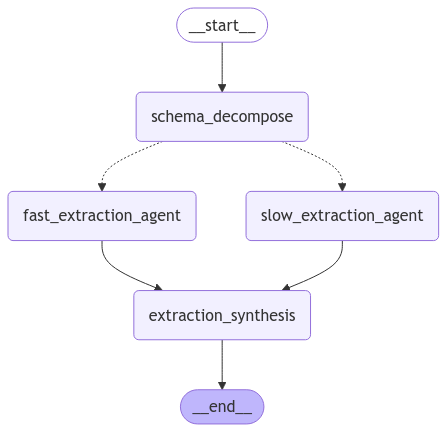

In [40]:
# Build the graph
graph_builder = StateGraph(State)
graph_builder.add_node("schema_decompose", schema_decompose)
graph_builder.add_node("fast_extraction_agent", fast_extraction_agent)
graph_builder.add_node("slow_extraction_agent", slow_extraction_agent)
graph_builder.add_node("extraction_synthesis", extraction_synthesis)
graph_builder.add_edge(START, "schema_decompose")
graph_builder.add_conditional_edges(
    "schema_decompose",
    fast_and_slow_route,
    {
        "fast_extraction_agent": "fast_extraction_agent",
        "slow_extraction_agent": "slow_extraction_agent",
    },
)
graph_builder.add_edge(
    ["fast_extraction_agent", "slow_extraction_agent"], "extraction_synthesis"
)
graph_builder.add_edge("extraction_synthesis", END)
# Compile the graph
graph = graph_builder.compile()

viz_graph(graph)

### F&S with DPE (Deep Extraction)
Validation loop.

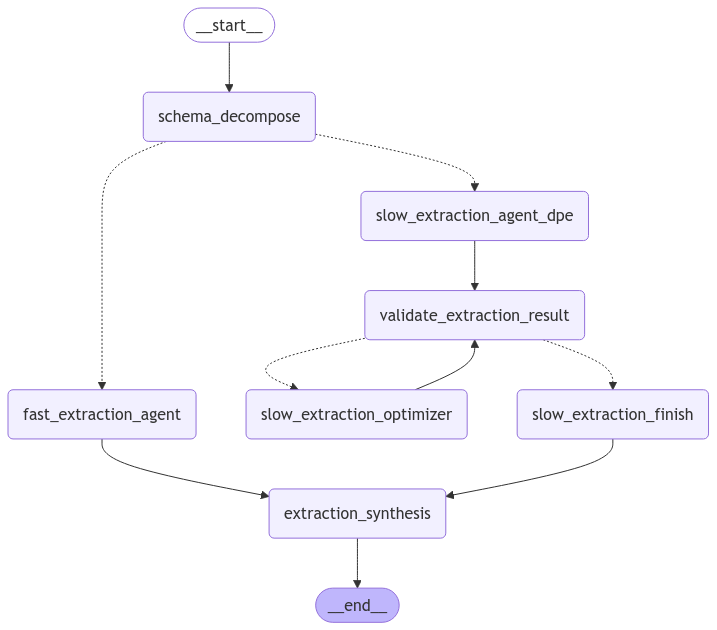

In [41]:
# Build the graph
graph_builder_dpe = StateGraph(State)
graph_builder_dpe.add_node("schema_decompose", schema_decompose)
graph_builder_dpe.add_node("fast_extraction_agent", fast_extraction_agent)
graph_builder_dpe.add_node("slow_extraction_agent_dpe", slow_extraction_agent_dpe)
graph_builder_dpe.add_node("slow_extraction_optimizer", slow_extraction_optimizer)
graph_builder_dpe.add_node("validate_extraction_result", validate_extraction_result)
graph_builder_dpe.add_node("slow_extraction_finish", slow_extraction_finish)
graph_builder_dpe.add_node("extraction_synthesis", extraction_synthesis)
graph_builder_dpe.add_edge(START, "schema_decompose")
graph_builder_dpe.add_conditional_edges(
    "schema_decompose",
    fast_and_slow_route,
    {
        "fast_extraction_agent": "fast_extraction_agent",
        "slow_extraction_agent_dpe": "slow_extraction_agent_dpe",
    },
)
graph_builder_dpe.add_edge("slow_extraction_agent_dpe", "validate_extraction_result")
graph_builder_dpe.add_edge("slow_extraction_optimizer", "validate_extraction_result")
graph_builder_dpe.add_conditional_edges(
    "validate_extraction_result",
    validate_extraction_result_route,
    {
        "slow_extraction_optimizer": "slow_extraction_optimizer",
        "slow_extraction_finish": "slow_extraction_finish",
    },
)
graph_builder_dpe.add_edge(
    ["fast_extraction_agent", "slow_extraction_finish"], "extraction_synthesis"
)
graph_builder_dpe.add_edge("extraction_synthesis", END)
# Compile the graph
graph_dpe = graph_builder_dpe.compile()

viz_graph(graph_dpe)

### F&S with DPE (Map Reduce)

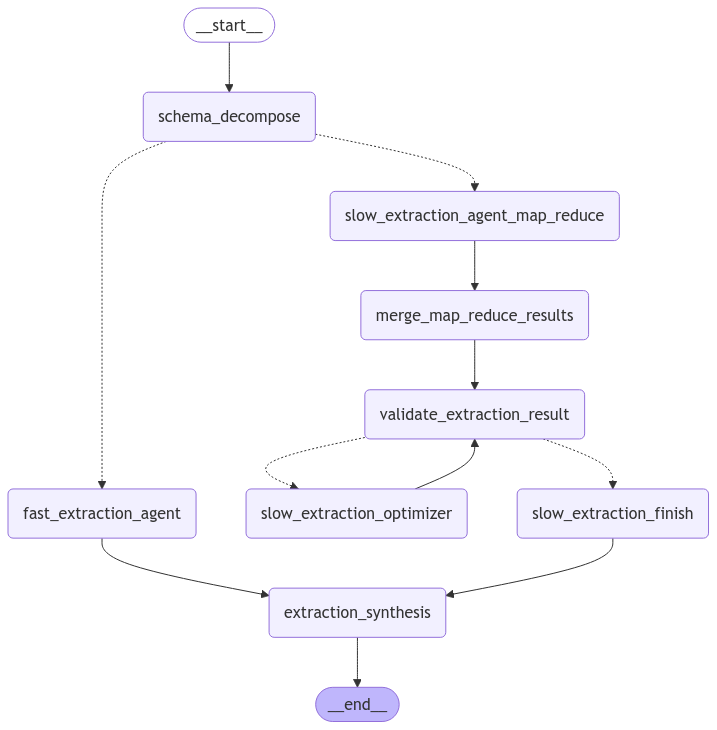

In [42]:
# Build the graph
graph_builder_dpe_map_reduce = StateGraph(State)
graph_builder_dpe_map_reduce.add_node("schema_decompose", schema_decompose)
graph_builder_dpe_map_reduce.add_node("fast_extraction_agent", fast_extraction_agent)
graph_builder_dpe_map_reduce.add_node(
    "slow_extraction_agent_map_reduce", slow_extraction_agent_map_reduce
)
graph_builder_dpe_map_reduce.add_node(
    "slow_extraction_optimizer", slow_extraction_optimizer
)
graph_builder_dpe_map_reduce.add_node(
    "validate_extraction_result", validate_extraction_result
)
graph_builder_dpe_map_reduce.add_node("slow_extraction_finish", slow_extraction_finish)
graph_builder_dpe_map_reduce.add_node(
    "merge_map_reduce_results", merge_map_reduce_results
)
graph_builder_dpe_map_reduce.add_node("extraction_synthesis", extraction_synthesis)
graph_builder_dpe_map_reduce.add_edge(START, "schema_decompose")
graph_builder_dpe_map_reduce.add_conditional_edges(
    "schema_decompose",
    fast_and_slow_route,
    ["fast_extraction_agent", "slow_extraction_agent_map_reduce"],
)
graph_builder_dpe_map_reduce.add_edge(
    "slow_extraction_agent_map_reduce", "merge_map_reduce_results"
)
graph_builder_dpe_map_reduce.add_edge(
    "merge_map_reduce_results", "validate_extraction_result"
)
graph_builder_dpe_map_reduce.add_conditional_edges(
    "validate_extraction_result",
    validate_extraction_result_route,
    ["slow_extraction_optimizer", "slow_extraction_finish"],
)
graph_builder_dpe_map_reduce.add_edge(
    "slow_extraction_optimizer", "validate_extraction_result"
)
graph_builder_dpe_map_reduce.add_edge(
    ["fast_extraction_agent", "slow_extraction_finish"], "extraction_synthesis"
)
graph_builder_dpe_map_reduce.add_edge("extraction_synthesis", END)
# Compile the graph
graph_dpe_map_reduce = graph_builder_dpe_map_reduce.compile()

viz_graph(graph_dpe_map_reduce)

## Run the Graphs
### Vanilla F&S

Batch extraction for both simple and complex entities.

In [41]:
for s in graph.stream(
    {
        "pdf_path": "data/raw/all_sources/43-101/02c1e1ca772fe97dfc2d3a8923ccccd3a090b79c3c74a92e6f1ff093b08cbf0a57.pdf",
        "json_schema": schema,
        "method": "F&S",
    },
):
    print(s)

2025-02-26 21:40:16.293 | DEBUG    | __main__:schema_decompose:79 - Response: <thinking>
"mineral_site_name", "country", and "state_or_province" are straightforward and can be extracted directly from the text as they represent simple attributes. The "total_grade", "total_tonnage", "top_1_deposit_type", and "top_1_deposit_environment" are more complex entities because they involve specific contextual information and may require additional reasoning or calculations to interpret the data accurately. For instance, "total_grade" and "total_tonnage" need to be understood in terms of their specific formats and implications. 
</thinking>
<output>
1. Simple entities: ["mineral_site_name", "country", "state_or_province"]
2. Complex entities: ["total_grade", "total_tonnage", "top_1_deposit_type", "top_1_deposit_environment"]
</output>
2025-02-26 21:40:16.294 | DEBUG    | __main__:schema_decompose:80 - Simple entities: ['mineral_site_name', 'country', 'state_or_province']
2025-02-26 21:40:16.295 |

{'schema_decompose': {'simple_entities': ['mineral_site_name', 'country', 'state_or_province'], 'complex_entities': ['total_grade', 'total_tonnage', 'top_1_deposit_type', 'top_1_deposit_environment'], 'fast_schema': {'type': 'object', 'properties': {'mineral_site_name': {'description': 'The name of the mineral site that the report is about', 'title': 'Mineral Site Name', 'type': 'string'}, 'country': {'description': 'The country where the mineral site is located', 'title': 'Country', 'type': 'string'}, 'state_or_province': {'description': 'The state or province where the mineral site is located', 'title': 'State Or Province', 'type': 'string'}}, 'required': ['mineral_site_name', 'country', 'state_or_province']}, 'slow_schema': {'type': 'object', 'properties': {'total_grade': {'default': 'Not Found', 'description': 'The total grade of all the nickel deposits in percentage format (e.g. 0.35% will be "0.35")', 'title': 'Total Grade', 'type': 'string'}, 'total_tonnage': {'default': 'Not Fo

2025-02-26 21:40:29.993 | DEBUG    | __main__:prompt_openai_assistant:27 - <retrieved>
The main mineral site name identified in the report is "Kun-Manie Nickel Project." It is located in Russia, specifically without a detailed state or province mentioned in the extracted content.
</retrieved>

<thinking>
I have determined the mineral site name to be "Kun-Manie Nickel Project" based on the content of the report. The country is identified as Russia. However, the specific state or province was not explicitly mentioned in the extracted text. I will structure this information according to the provided JSON schema.
</thinking>

<json>
{
  "mineral_site_name": "Kun-Manie Nickel Project",
  "country": "Russia",
  "state_or_province": ""
}
</json>


{'fast_extraction_agent': {'fast_extraction_agent_result': {'mineral_site_name': 'Kun-Manie Nickel Project', 'country': 'Russia', 'state_or_province': ''}}}


2025-02-26 21:40:34.739 | DEBUG    | __main__:prompt_openai_assistant:27 - <retrieved>
The main mineral site name from the report is "Kun-Manie Nickel Project". The relevant entities extracted from the report include:

- Total Grade: 0.48%
- Total Tonnage: 53.3 million tonnes
- Top 1 Deposit Type: Not Found (not explicitly mentioned)
- Top 1 Deposit Environment: Not Found (not explicitly mentioned)
</retrieved>

<thinking>
The Kun-Manie Nickel Project is the central focus of the report, which provides detailed mineral resource estimates. The total grade of the nickel deposits is given as 0.48%, and the total tonnage is reported to be 53.3 million tonnes. However, specific details regarding the top deposit type and environment are not explicitly stated in the extracted sections. Therefore, these fields will be marked as "Not Found".
</thinking>

<json>
{
  "total_grade": "0.48",
  "total_tonnage": "53.3",
  "top_1_deposit_type": "Not Found",
  "top_1_deposit_environment": "Not Found"
}


{'slow_extraction_agent': {'slow_extraction_agent_result': {'total_grade': '0.48', 'total_tonnage': '53.3', 'top_1_deposit_type': 'Not Found', 'top_1_deposit_environment': 'Not Found'}}}
{'extraction_synthesis': {'final_extraction_result': MineralSiteMetadata(mineral_site_name='Kun-Manie Nickel Project', country='Russia', state_or_province='', total_grade='0.48', total_tonnage='53.3', top_1_deposit_type='Not Found', top_1_deposit_environment='Not Found')}}


### F&S with DPE

In [28]:
import sys

from langgraph.errors import GraphRecursionError

try:
    result = graph_dpe.invoke(
        {
            "pdf_path": "data/raw/all_sources/43-101/02c1e1ca772fe97dfc2d3a8923ccccd3a090b79c3c74a92e6f1ff093b08cbf0a57.pdf",
            "json_schema": schema,
            "method": "DPE",
        },
        {"recursion_limit": 12},
    )
except GraphRecursionError as e:
    logger.error(f"Recursion Error: {e}")
print(result["final_extraction_result"].model_dump_json(indent=4))

2025-02-26 22:08:20.092 | DEBUG    | __main__:schema_decompose:79 - Response: <thinking>
"mineral_site_name", "country", and "state_or_province" are simple entities that can be extracted directly from the text. The "total_grade" and "total_tonnage" are complex entities because they require calculating or interpreting values based on the context of nickel deposits and may need additional information to understand the percentage and tonnage in the required format. The "top_1_deposit_type" and "top_1_deposit_environment" are also complex entities as they require knowledge about the mineral site and its characteristics to determine the most likely deposit type and environment.
</thinking>
<output>
1. Simple entities: ["mineral_site_name", "country", "state_or_province"]
2. Complex entities: ["total_grade", "total_tonnage", "top_1_deposit_type", "top_1_deposit_environment"]
</output>
2025-02-26 22:08:20.093 | DEBUG    | __main__:schema_decompose:80 - Simple entities: ['mineral_site_name', '

{
    "mineral_site_name": "Kun-Manie",
    "country": "Russia",
    "state_or_province": "Amur",
    "total_grade": "0.48",
    "total_tonnage": "53.3",
    "top_1_deposit_type": "Nickel sulfide",
    "top_1_deposit_environment": "Intrusive igneous"
}


In [34]:
try:
    result = graph_dpe.invoke(
        {
            "pdf_path": "data/raw/all_sources/43-101/02c1ca57538c379d05d9f65f1cbd8570786c2398e24dcc600abf92e617207046a2.pdf",
            "json_schema": schema,
            "method": "DPE",
        },
        {"recursion_limit": 12},
    )
except GraphRecursionError as e:
    logger.error(f"Recursion Error: {e}")

print(result["final_extraction_result"].model_dump_json(indent=4))

2025-02-26 18:29:44.449 | DEBUG    | __main__:schema_decompose:72 - Response: <thinking>
The entities "mineral_site_name", "country", and "state_or_province" are simple entities that can be extracted directly from the text. However, "total_grade" and "total_tonnage" are complex entities as they can be either a number or a string and require reasoning about the format of the data being extracted. The "top_1_deposit_type" and "top_1_deposit_environment" are also simple entities but their default values suggest they may not always be present, which adds a layer of complexity in ensuring data completeness. However, since they can be extracted directly when present, they are still classified as simple entities.
</thinking>
<output>
1. Simple entities: ["mineral_site_name", "country", "state_or_province", "top_1_deposit_type", "top_1_deposit_environment"]
2. Complex entities: ["total_grade", "total_tonnage"]
</output>
2025-02-26 18:29:44.450 | DEBUG    | __main__:schema_decompose:73 - Simple

In [ ]:
try:
    result = graph_dpe.invoke(
        {
            "pdf_path": "data/raw/all_sources/43-101/021a794659a5c972b322e3bda39a1740793bb55223899eca13766ca7e84abdfded.pdf",
            "json_schema": schema,
            "method": "DPE",
        },
        {"recursion_limit": 12},
    )
except GraphRecursionError as e:
    logger.error(f"Recursion Error: {e}")

print(result["final_extraction_result"].model_dump_json(indent=4))

2025-02-26 21:06:57.648 | INFO     | __main__:fast_and_slow_route:96 - Routing to the appropriate extraction agent
2025-02-26 21:06:57.650 | INFO     | __main__:fast_extraction_agent:137 - Batch extracting simple entities from the 43-101 report
2025-02-26 21:06:57.652 | INFO     | __main__:slow_extraction_agent_dpe:172 - Deep extraction of complex entities from the 43-101 report
2025-02-26 21:06:57.653 | INFO     | __main__:slow_extraction_agent_dpe:179 - Extracting entities from the 43-101 report
2025-02-26 21:06:57.653 | INFO     | __main__:deep_extract:44 - Extracting total_grade from data/raw/all_sources/43-101/021a794659a5c972b322e3bda39a1740793bb55223899eca13766ca7e84abdfded.pdf


### F&S DPE with Map Reduce

In [43]:
try:
    result = graph_dpe_map_reduce.invoke(
        {
            "pdf_path": "data/raw/all_sources/43-101/021a794659a5c972b322e3bda39a1740793bb55223899eca13766ca7e84abdfded.pdf",
            "json_schema": schema,
            "method": "DPE + MAP_REDUCE",
        },
        {"recursion_limit": 12},
    )
except GraphRecursionError as e:
    logger.error(f"Recursion Error: {e}")

print(result["final_extraction_result"].model_dump_json(indent=4))

2025-02-26 22:21:41.547 | DEBUG    | __main__:schema_decompose:79 - Response: <thinking>
"mineral_site_name", "country", and "state_or_province" can be extracted directly from the text as they represent straightforward information. However, "total_grade", "total_tonnage", "top_1_deposit_type", and "top_1_deposit_environment" may require additional context or reasoning to extract, as they involve interpreting the descriptions and potentially calculating or categorizing data based on the descriptions given.
</thinking>
<output>
1. Simple entities: ["mineral_site_name", "country", "state_or_province"]
2. Complex entities: ["total_grade", "total_tonnage", "top_1_deposit_type", "top_1_deposit_environment"]
</output>
2025-02-26 22:21:41.548 | DEBUG    | __main__:schema_decompose:80 - Simple entities: ['mineral_site_name', 'country', 'state_or_province']
2025-02-26 22:21:41.549 | DEBUG    | __main__:schema_decompose:81 - Complex entities: ['total_grade', 'total_tonnage', 'top_1_deposit_type',

{
    "mineral_site_name": "Wolf Mountain Property",
    "country": "Canada",
    "state_or_province": "Ontario",
    "total_grade": "Not Found",
    "total_tonnage": "Not Found",
    "top_1_deposit_type": "Noril'sk-type",
    "top_1_deposit_environment": "Not Found"
}
